In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [3]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [4]:
acdata = pd.read_csv("./dataset/accelerometer_data.csv")
print(acdata.head())

   No  accX  accY  accZ  activity
0   0  1502  2215  2215         1
1   1  1667  2072  2072         1
2   2  1611  1957  1957         1
3   3  1601  1939  1939         1
4   4  1643  1965  1965         1


In [7]:
def genTimeStepData(ts, fcol, tcol, ntimesteps):   
    X = []
    y = []
    dcol = ts.loc[:, fcol]
    #print(dcol.shape)
    lcol = ts.loc[:, tcol]
    #print(lcol.shape)
    for i in range(ntimesteps, dcol.shape[0]):
        X.append(list(dcol.loc[i-ntimesteps:i-1]))
        y.append(lcol[i])
    X, y = np.array(X), np.array(y)
    return X, y

In [9]:
X_train, y_all = genTimeStepData(acdata, "accX", "activity", 60)

print(X_train.shape)
print(X_train[0])
print(y_all.shape)

(162441, 60)
[1502 1667 1611 1601 1643 1604 1640 1607 1546 1529 1637 1596 1590 1601
 1542 1598 1511 1555 1508 1580 1627 1592 1634 1638 1593 1542 1601 1613
 1644 1642 1605 1586 1577 1598 1561 1628 1694 1627 1598 1612 1630 1609
 1600 1608 1612 1605 1640 1610 1633 1573 1568 1576 1599 1620 1654 1637
 1603 1605 1620 1616]
(162441,)


In [10]:

X_train, y_all =  genTimeStepData(acdata, "accX", "activity", 60)

Y_train, y_all =  genTimeStepData(acdata, "accY", "activity", 60)

Z_train, y_all =  genTimeStepData(acdata, "accY", "activity", 60)

X_all = np.concatenate((X_train, Y_train), axis = 1)
X_all =  np.concatenate((X_all, Z_train), axis = 1)

print(X_all.shape)
print(y_all.shape)

(162441, 180)
(162441,)


In [11]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [13]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [17]:
acdata = pd.read_csv("./dataset/accelerometer_data.csv")

In [19]:
class_name = ["", "Working at Computer", "Walking up-down", "Standing", "Walking", "Going up-down", "Walking-Talking", "Talking-Standing"]

In [21]:
def generateTimeStepData(ts, fcol, tcol, ntimesteps):   
    X = []
    y = []
    dcol = ts.loc[:, fcol]
    #print(dcol.shape)
    lcol = ts.loc[:, tcol]
    #print(lcol.shape)
    for i in range(ntimesteps, dcol.shape[0]):
        X.append(list(dcol.loc[i-ntimesteps:i-1]))
        y.append(lcol[i])
    X, y = np.array(X), np.array(y)
    return X, y

In [23]:

X_train, y_all =  genTimeStepData(acdata, "accX", "activity", 120)
Y_train, y_all =  genTimeStepData(acdata, "accY", "activity", 120)
Z_train, y_all =  genTimeStepData(acdata, "accZ", "activity", 120)

X_all = np.concatenate((X_train, Y_train), axis = 1)
X_all =  np.concatenate((X_all, Z_train), axis = 1)

print(X_all.shape)
print(y_all.shape)

(162381, 360)
(162381,)


In [25]:
X_train, X_test, y_train, y_test =  train_test_split(X_all, y_all, test_size=0.2)

In [35]:

y_train = tf.keras.utils.to_categorical(y_train, num_classes = 8).astype('int32')

y_test = tf.keras.utils.to_categorical(y_test, num_classes = 8).astype('int32')

print(X_train.shape)
print(y_train.shape)

(129904, 360)
(129904, 8)


In [37]:
X_train = X_train.reshape(X_train.shape[0], 120, 3).astype('float32')
X_test = X_test.reshape(X_test.shape[0], 120, 3).astype('float32') 

print(X_train.shape)
print(X_test.shape)

(129904, 120, 3)
(32477, 120, 3)


In [39]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(120, 3)))
model.add(tf.keras.layers.Conv1D(filters = 10, kernel_size = 5))
model.add(tf.keras.layers.GlobalMaxPool1D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(100, activation='relu'))
model.add(tf.keras.layers.Dense(y_train.shape[1], activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 116, 10)             │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 10)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │           1,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             808 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,068 (8.08 KB)

 Trainable params: 2,068 (8.08 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [43]:
history = model.fit(X_train, y_train, epochs =50, verbose =1, validation_data=(X_test, y_test))


Epoch 1/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.6960 - loss: 9.4334 - val_accuracy: 0.7785 - val_loss: 0.8921
Epoch 2/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8118 - loss: 0.9488 - val_accuracy: 0.7561 - val_loss: 0.9083
Epoch 3/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.8387 - loss: 0.6248 - val_accuracy: 0.7968 - val_loss: 0.6635
Epoch 4/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 19s 5ms/step - accuracy: 0.8394 - loss: 0.6120 - val_accuracy: 0.8657 - val_loss: 0.5117
Epoch 5/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.8456 - loss: 0.5860 - val_accuracy: 0.8706 - val_loss: 0.4762
Epoch 6/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8516 - loss: 0.5473 - val_accuracy: 0.8689 - val_loss: 0.4756
Epoch 7/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8584 - loss: 0.5123 - val_accuracy: 0.8722 - val_loss: 0.4628
Epoch 8/50
4060/4060 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.8610 - loss: 0

In [45]:
# Evaluate the model

scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))


Accuracy: 87.32%


In [47]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    x = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(x, acc, 'b', label='Training acc')
    plt.plot(x, val_acc, 'r', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(x, loss, 'b', label='Training loss')
    plt.plot(x, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

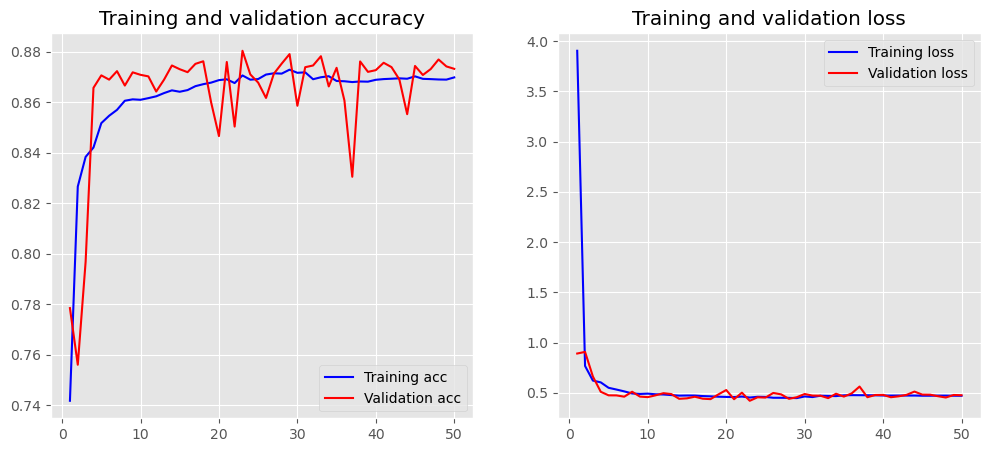

In [49]:
plot_history(history)

In [51]:
class_name = ["", "Working at Computer", "Walking up-down", "Standing", "Walking", "Going up-down", "Walking-Talking", "Talking-Standing"]
cpredict = model.predict(X_test)

#Display 10 data of actual and predicted data

for i,y in zip(cpredict[:10], y_test[:10]):    
    invertedy = np.argmax(y)    
    invertedp = np.argmax(i)    
    print(class_name[invertedy], class_name[invertedp])

1015/1015 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Talking-Standing Talking-Standing
Standing Talking-Standing
Walking Walking
Walking Walking
Working at Computer Working at Computer
Standing Talking-Standing
Working at Computer Working at Computer
Talking-Standing Talking-Standing
Walking Walking
Walking Walking


In [53]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [55]:
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn import preprocessing
import os
import sys
from tensorflow.keras.callbacks import ModelCheckpoint
from scipy import stats


In [57]:
#Read the dataset into a pandas.DataFrame

wdata = pd.read_csv("./dataset/PRSA_data.csv")
print(wdata.shape)
print(wdata.head())

(43824, 14)
   No  year  month  day  hour  pm2.5  DEWP  TEMP    PRES cbwd    Iws  Is  Ir  \
0   1  2010      1    1     0    NaN   -21 -11.0  1021.0   NW   1.79   0   0   
1   2  2010      1    1     1    NaN   -21 -12.0  1020.0   NW   4.92   0   0   
2   3  2010      1    1     2    NaN   -21 -11.0  1019.0   NW   6.71   0   0   
3   4  2010      1    1     3    NaN   -21 -14.0  1019.0   NW   9.84   0   0   
4   5  2010      1    1     4    NaN   -20 -12.0  1018.0   NW  12.97   0   0   

              datetime  
0  2010-01-01 00:00:00  
1  2010-01-01 01:00:00  
2  2010-01-01 02:00:00  
3  2010-01-01 03:00:00  
4  2010-01-01 04:00:00  


In [59]:
X = wdata['PRES'].to_numpy().reshape(-1, 1)
print(X.shape)
scaler = preprocessing.MinMaxScaler()
x_scaled = scaler.fit_transform(X)
wdata['scaled_PRES'] = x_scaled

(43824, 1)


In [61]:
def genTimestepData1(ts, fcol, ntimesteps):    
    X = []
    y = []
    dcol = ts.loc[:, fcol]
    #print(stats.tmean(dcol.loc[50-ntimesteps:50-1]))
    for i in range(ntimesteps, dcol.shape[0]):
        X.append(list(dcol.loc[i-ntimesteps:i-1]))        
        y.append(stats.tmean(dcol.loc[i-ntimesteps:i-1]))
        #y.append(dcol.loc[i])
    X, y = np.array(X), np.array(y)
    return X, y

In [63]:
X_all, y_all = genTimestepData1(wdata, "scaled_PRES", 7)


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2)

In [67]:
X_train = X_train.reshape(X_train.shape[0], 7, 1)
X_test = X_test.reshape(X_test.shape[0], 7, 1)

print(X_train.shape)
print(X_test.shape)


(35053, 7, 1)
(8764, 7, 1)


In [69]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(7, 1)))
model.add(tf.keras.layers.Conv1D(filters = 64, kernel_size = 3))
model.add(tf.keras.layers.GlobalMaxPool1D())
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(1, activation='linear'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)                    │ (None, 5, 64)               │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_1               │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
model.compile(optimizer='adam', loss = 'mean_absolute_error')

In [103]:
save_weights_at = os.path.join('models', 'AIRPRES_1DConv_weights_{epoch:02d}-{val_loss:.4f}.keras')
save_best = ModelCheckpoint(save_weights_at, monitor='val_loss', verbose=0, save_best_only=True, save_weights_only=False)

In [105]:
model.fit(X_train, y_train, batch_size=16, epochs=20, verbose=1, callbacks=[save_best], 
validation_data=(X_test, y_test),shuffle=True)

Epoch 1/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0090 - val_loss: 0.0024
Epoch 2/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0089 - val_loss: 0.0016
Epoch 3/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0088 - val_loss: 0.0022
Epoch 4/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0088 - val_loss: 0.0041
Epoch 5/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0086 - val_loss: 0.0025
Epoch 6/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0087 - val_loss: 0.0033
Epoch 7/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0087 - val_loss: 0.0029
Epoch 8/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0087 - val_loss: 0.0021
Epoch 9/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0087 - val_loss: 0.0022
Epoch 10/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0087 - val_loss: 0.0019
Epoch 11/20
2191/2191 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.0087 - val_loss: 0.0013
Epoch 12/20
2191/2191 ━━━━━━━━

In [109]:
import os
os.makedirs("./models", exist_ok=True)
print(os.listdir("./models"))

['AIRPRES_1DConv_weights_01-0.0024.keras', 'AIRPRES_1DConv_weights_01-0.0056.keras', 'AIRPRES_1DConv_weights_02-0.0016.keras', 'AIRPRES_1DConv_weights_03-0.0024.keras', 'AIRPRES_1DConv_weights_07-0.0015.keras', 'AIRPRES_1DConv_weights_11-0.0013.keras', 'AIRPRES_1DConv_weights_12-0.0014.keras']


In [111]:

best_model = tf.keras.models.load_model("./models/AIRPRES_1DConv_weights_01-0.0024.keras")

preds = best_model.predict(X_test)

pred_PRES = scaler.inverse_transform(preds)
print(pred_PRES[:10])


274/274 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[1026.4493 ]
 [1001.9488 ]
 [ 999.46497]
 [1029.9481 ]
 [1016.1645 ]
 [1012.94244]
 [1021.211  ]
 [1019.318  ]
 [1022.3836 ]
 [1017.19934]]


In [113]:
from sklearn.metrics import r2_score

org_PRES = scaler.inverse_transform(y_test.reshape(-1, 1))

r2 = r2_score(org_PRES, pred_PRES)

print('R-squared for the validation set:', round(r2, 4))


R-squared for the validation set: 0.9998


Text(0.5, 0, 'Index')

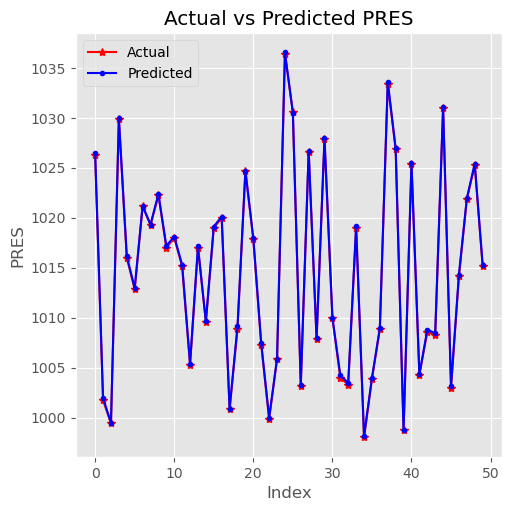

In [157]:

plt.figure(figsize=(5.5, 5.5))
plt.plot(range(50), org_PRES[:50], linestyle='-', marker='*', color='r')

plt.plot(range(50), pred_PRES[:50], linestyle='-', marker='.', color='b')

plt.legend(['Actual','Predicted'], loc=2)
plt.title('Actual vs Predicted PRES')
plt.ylabel('PRES')
plt.xlabel('Index')
